In [1]:
# Завантаження потрібних для роботи бібліотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

1. Зчитай дані з файлу та виведи інформацію про результати A/B тесту.

In [2]:
# Зчитаємо дані з файлу та виводимо інформацію про результати A/B тесту.

# ID файлу
file_id = '1pySA0Ly6TbMMsUPFhbCn7GSiy-vwKiDQ'

# Формуємо пряме посилання для завантаження
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Читаємо CSV файл напряму в DataFrame
try:
    ab_test_data = pd.read_csv(url)
    print("Файл успішно завантажено!")
    print(ab_test_data.head())
except Exception as e:
    print("Помилка завантаження. Перевірте, чи файл має відкритий доступ за посиланням.")
    print(f"Деталі помилки: {e}")


Файл успішно завантажено!
                                user_id                   timestamp  \
0  7f6833e6-1141-4f20-b4b2-f1e31019b1fd  2023-07-04 04:40:55.848109   
1  e6a6e960-d3f3-4074-a516-ba1e609b211e  2023-07-06 00:26:45.486187   
2  4d3fbfa5-6847-410a-bac2-477f01d5f400  2023-07-10 20:24:33.639464   
3  361457d9-a044-48f7-981c-d67dc3861679  2023-07-20 07:04:49.957013   
4  285cd63d-7d03-427f-a062-1fa2dd2e77d6  2023-07-19 23:27:50.116680   

  test_group  conversion  
0          a           0  
1          b           0  
2          b           0  
3          b           0  
4          b           0  


In [3]:
# Попередній аналіз та підготовка даних
# Для зручності подальшого аналізу та розрахунку метрик (конверсії, дат), 
# я розділив загальний датасет на дві окремі групи: Контрольну (A) та Тестову (B). 
# Це дозволить уникнути помилок при постійній фільтрації основної таблиці.
# Так як "timestamp" це текст, я перетворюю в дату та прибераю мікросекунди
ab_test_data['timestamp'] = pd.to_datetime(ab_test_data['timestamp']).dt.round('s')

count_group_a = ab_test_data[ab_test_data['test_group'] == 'a'].copy()
count_group_b = ab_test_data[ab_test_data['test_group'] == 'b'].copy()

2. Кількість користувачів в групах A та B відповідно.

In [4]:
# Виводимо кількість користувачів по групам
print("-" * 52)
print(f"Кількість користувачів в групі A (Контрольна): {len(count_group_a)}")
print(f"Кількість користувачів в групі B (Тестова): {len(count_group_b)}")
print("-" * 52)

----------------------------------------------------
Кількість користувачів в групі A (Контрольна): 10013
Кількість користувачів в групі B (Тестова): 9985
----------------------------------------------------


3. Кількість конверсій в групах A та B відповідно.

In [5]:
# Кількість конверсій в групах A та B.
print("-" * 47)
print(f"Кількість конверсій в групі A (Контрольна): {count_group_a['conversion'].sum()}")
print(f"Кількість конверсій в групі B (Тестова): {count_group_b['conversion'].sum()}")
print("-" * 47)

-----------------------------------------------
Кількість конверсій в групі A (Контрольна): 611
Кількість конверсій в групі B (Тестова): 889
-----------------------------------------------


4. Рівень конверсії в групах A та B відповідно.

In [6]:
# Рівень конверсії в групах A та B

print("-" * 46)
print(f"Рівень конверсії в групі A (Контрольна): {count_group_a['conversion'].mean():.2%}")
print(f"Рівень конверсії в групі B (Тестова): {count_group_b['conversion'].mean():.2%}")
print("-" * 46)

----------------------------------------------
Рівень конверсії в групі A (Контрольна): 6.10%
Рівень конверсії в групі B (Тестова): 8.90%
----------------------------------------------


5. Дату початку та дату кінця тесту, а також тривалість тесту в днях.

In [7]:
# 1. Визначаю початок і кінець для кожної групи окремо
# Група А (Контрольна):
start_a = count_group_a['timestamp'].min()
finish_a = count_group_a['timestamp'].max()
# Група B (Тестова):
start_b = count_group_b['timestamp'].min()
finish_b = count_group_b['timestamp'].max()
# Вивожу дані початку та кінця старту та фінішу груп
print("-" * 47)
print(f"Старт групи А (Контрольна): {start_a}")
print(f"Старт групи B (Тестова):    {start_b}")
print("-" * 47)
print(f"Фініш групи А (Контрольна): {finish_a}")
print(f"Фініш групи B (Тестова):    {finish_b}")
print("-" * 47)

# 2. Визначаємо дати початку та кінця
start_date = ab_test_data['timestamp'].min()
end_date = ab_test_data['timestamp'].max()
# 3. Тривалість тесту в днях
days_in_test = (ab_test_data['timestamp'].max() - ab_test_data['timestamp'].min())
# 
# Вивожу дані початку та кінця старту A/B тестування
# "Тривалість тесту в тижнях" стало цікаво чи можна таким чином вивести, спробував получилось
print(f"""
Дата початку тесту:         {start_date}
Дата кінця тесту:           {end_date}
Тривалість тесту в днях:    {days_in_test.days} днів
Тривалість тесту в тижнях:  {days_in_test.days // 7} тижні та {days_in_test.days % 7} днів \U0001F60A
""")
print("-" * 47) 

-----------------------------------------------
Старт групи А (Контрольна): 2023-07-03 01:46:15
Старт групи B (Тестова):    2023-07-03 01:42:34
-----------------------------------------------
Фініш групи А (Контрольна): 2023-07-25 01:41:19
Фініш групи B (Тестова):    2023-07-25 01:35:59
-----------------------------------------------

Дата початку тесту:         2023-07-03 01:42:34
Дата кінця тесту:           2023-07-25 01:41:19
Тривалість тесту в днях:    21 днів
Тривалість тесту в тижнях:  3 тижні та 0 днів 😊

-----------------------------------------------


6. Обери статистичний критерій для тестування гіпотез на свій розсуд та обрахуй значення статистики та p-value. Перевір, чи можемо ми відхили нульову гіпотезу. Не забудь уточнити, який критерій використовуєш.

In [8]:
# Задаємо рівень значущості
alpha = 0.05

# Створюємо таблицю спряженості
observed = pd.crosstab(ab_test_data['test_group'], ab_test_data['conversion'], rownames=['Група'], colnames=['Конверсія'])
print("-" * 26)
print("Таблиця фактичних значень:")
print(observed)
print("-" * 38)

# 3. Виконуємо тест Хі-квадрат (використовуємо для категоріальних даних, як конверсія)
statistic, pvalue, dof, expected_values = stats.chi2_contingency(observed)

print(f'chi2-statistic: {statistic:.2f}')
print(f'p-value:        {pvalue:.20f}')
print("-" * 38)

if pvalue < alpha:
    print(f'p-value {round(pvalue, 4)} < {alpha}.')
    print('Результат: Різниця є статистично значущою, нульова гіпотеза (H0) відхиляється.')
else:
    print(f'p-value {round(pvalue, 4)} >= {alpha}.')
    print('Результат: Різниця статистично непідтверджена, нульову гіпотезу (H0) не можна відхилити.')
print("-" * 78)

--------------------------
Таблиця фактичних значень:
Конверсія     0    1
Група               
a          9402  611
b          9096  889
--------------------------------------
chi2-statistic: 56.14
p-value:        0.00000000000006740441
--------------------------------------
p-value 0.0 < 0.05.
Результат: Різниця є статистично значущою, нульова гіпотеза (H0) відхиляється.
------------------------------------------------------------------------------


7. Побудуй візуалізацію для порівняння середніх значень у групах з 95% довірчими інтервалами.

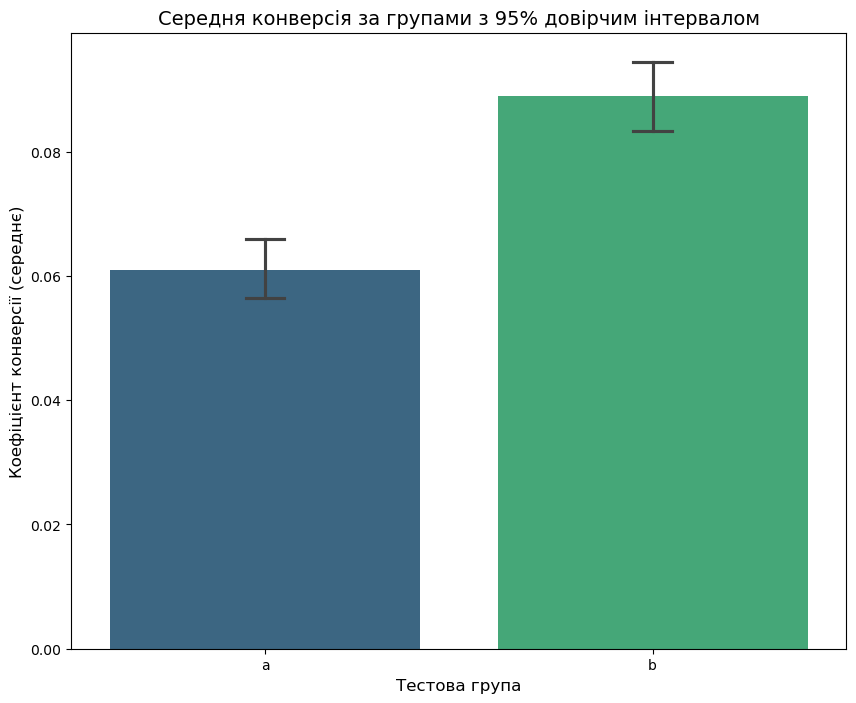

In [9]:
# Побудова візуалізації для порівняння середніх значень у групах з 95% довірчими інтервалами.
plt.figure(figsize=(10, 8))

sns.barplot(data = ab_test_data,
            x = 'test_group', 
            y = 'conversion',            
            errorbar = ('ci', 95), # Довірчий інтервал 95%
            palette = 'viridis',
            hue = 'test_group',
            capsize = 0.1
           )

plt.title('Середня конверсія за групами з 95% довірчим інтервалом', fontsize=14)
plt.xlabel('Тестова група', fontsize=12)
plt.ylabel('Коефіцієнт конверсії (середнє)', fontsize=12)

# Збереження графіка у файл
# plt.savefig('ab_test_barplot.png', dpi=300, bbox_inches='tight')

plt.show()

8. Підготуй висновки про результати A/B тесту згідно з рекомендаціями, з якими ми ознайомились в цій темі.

Висновки та візуалізація оформлені у форматі PDF-звіту, що додається до роботи

Бонусне завдання

Побудуй графік, що відображатиме зміну конверсії в часі. І не забувай врахувати, що на цей раз в нас дійсно є дані про час здійснення івенту.

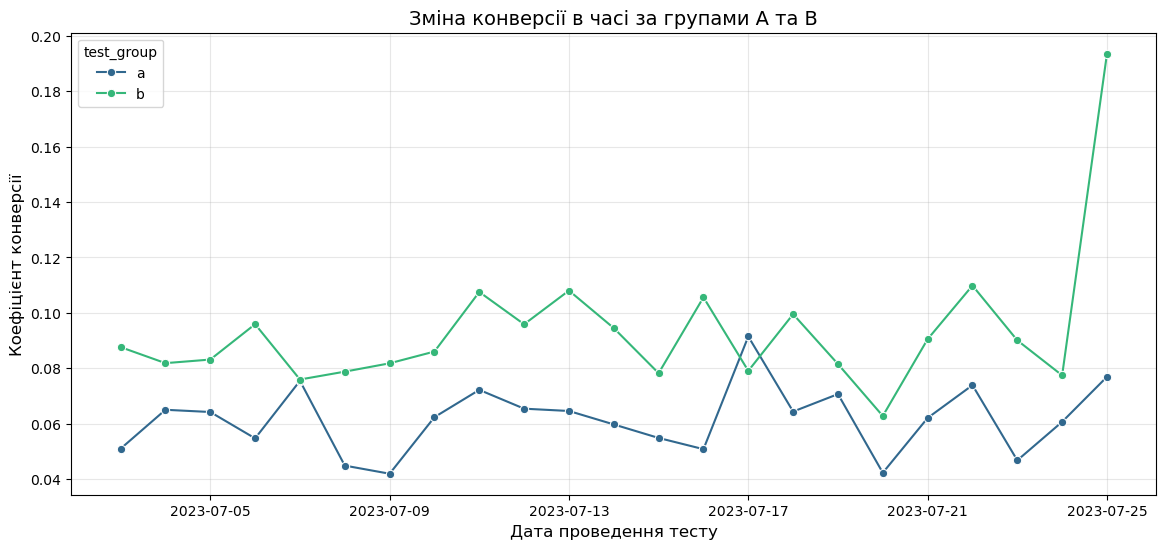

In [10]:
# Створюю копію даних для графіка (щоб не пошкодити основний датасет)
time_ab_test_data = ab_test_data.copy()

# Групуємо дані по днях і групах, рахуючи середню конверсію за кожен день
daily_conv = time_ab_test_data.groupby([time_ab_test_data['timestamp'].dt.date, 'test_group'])['conversion'].mean().reset_index()

# Побудова лінійного графіка
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_conv, x='timestamp', y='conversion', hue='test_group', marker='o', palette='viridis')

plt.title('Зміна конверсії в часі за групами A та B', fontsize=14)
plt.xlabel('Дата проведення тесту', fontsize=12)
plt.ylabel('Коефіцієнт конверсії', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()